# Flight Price Prediction

| No | Feature Name        | Type        | Description |
|----|--------------------|------------|-------------|
| 1  | Airline            | Categorical | 6 different airline companies |
| 2  | Flight             | Categorical | Flight code of the plane |
| 3  | Source City        | Categorical | Departure city (6 unique cities) |
| 4  | Departure Time     | Categorical | Time bin of departure (6 labels) |
| 5  | Stops              | Categorical | Number of stops (3 values) |
| 6  | Arrival Time       | Categorical | Time bin of arrival (6 labels) |
| 7  | Destination City   | Categorical | Arrival city (6 unique cities) |
| 8  | Class              | Categorical | Seat class (Economy / Business) |
| 9  | Duration           | Continuous   | Flight duration in hours |
| 10 | Days Left          | Continuous   | Days between booking and flight |
| 11 | Price              | Target       | Ticket price |

In [ ]:
#Essential Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

import warnings

# Ignore Warnings
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 8)

In [2]:
df = pd.read_csv("Clean_Dataset.csv")

In [3]:
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [91]:
df.drop("Unnamed: 0", axis= 1, inplace= True)

KeyError: "['Unnamed: 0'] not found in axis"

In [5]:
df

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [6]:
df.shape

(300153, 11)

In [7]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [9]:
df.isnull().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

# Exploratory Data Analysis(EDA)

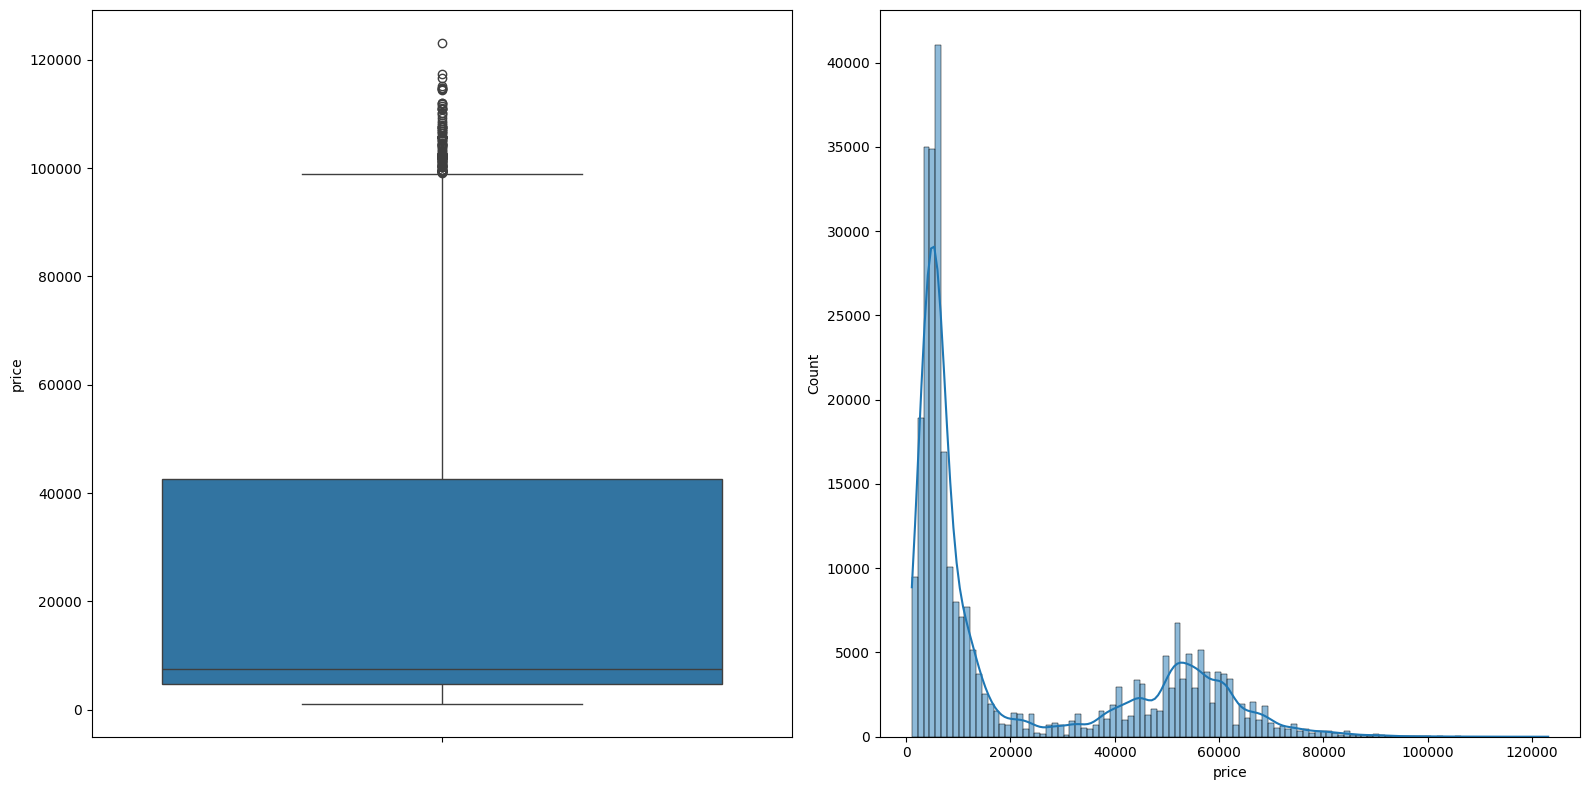

In [ ]:
# Feature Analysis
fig, ax = plt.subplots(1, 2, figsize = (16,8))

sns.boxplot(
    df["price"],
    ax = ax[0]
    )

sns.histplot(
    df["price"],
    kde= True,
    ax= ax[1]
    )

plt.tight_layout()
plt.show()

In [11]:
skewness = df["price"].skew()
kurtosis = df["price"].kurt()

print(f"Skewness of the Target = {skewness}")
print(f"Kurtosis of the Target = {kurtosis}")


Skewness of the Target = 1.0613772532064343
Kurtosis of the Target = -0.3962927186960772


In [12]:
q1, q2, q3 = df["price"].quantile([0.25, 0.5, 0.75])
iqr = q3 - q1
upper_bound = q3 + iqr * 1.5
lower_bound = q1 - iqr * 1.5

outliers = []
for value in df["price"]:
    if value < lower_bound or value > upper_bound:
        outliers.append(value)

print(f"Q1 : {q1}\nQ2 : {q2}\nQ3 : {q3}")
print(f"Inter Quartile Ranges = {iqr}")
print(f"Upper Bound = {upper_bound}\nLower Bound {lower_bound}")
print(f"Numbers of Outliers : {len(outliers)}")

Q1 : 4783.0
Q2 : 7425.0
Q3 : 42521.0
Inter Quartile Ranges = 37738.0
Upper Bound = 99128.0
Lower Bound -51824.0
Numbers of Outliers : 123


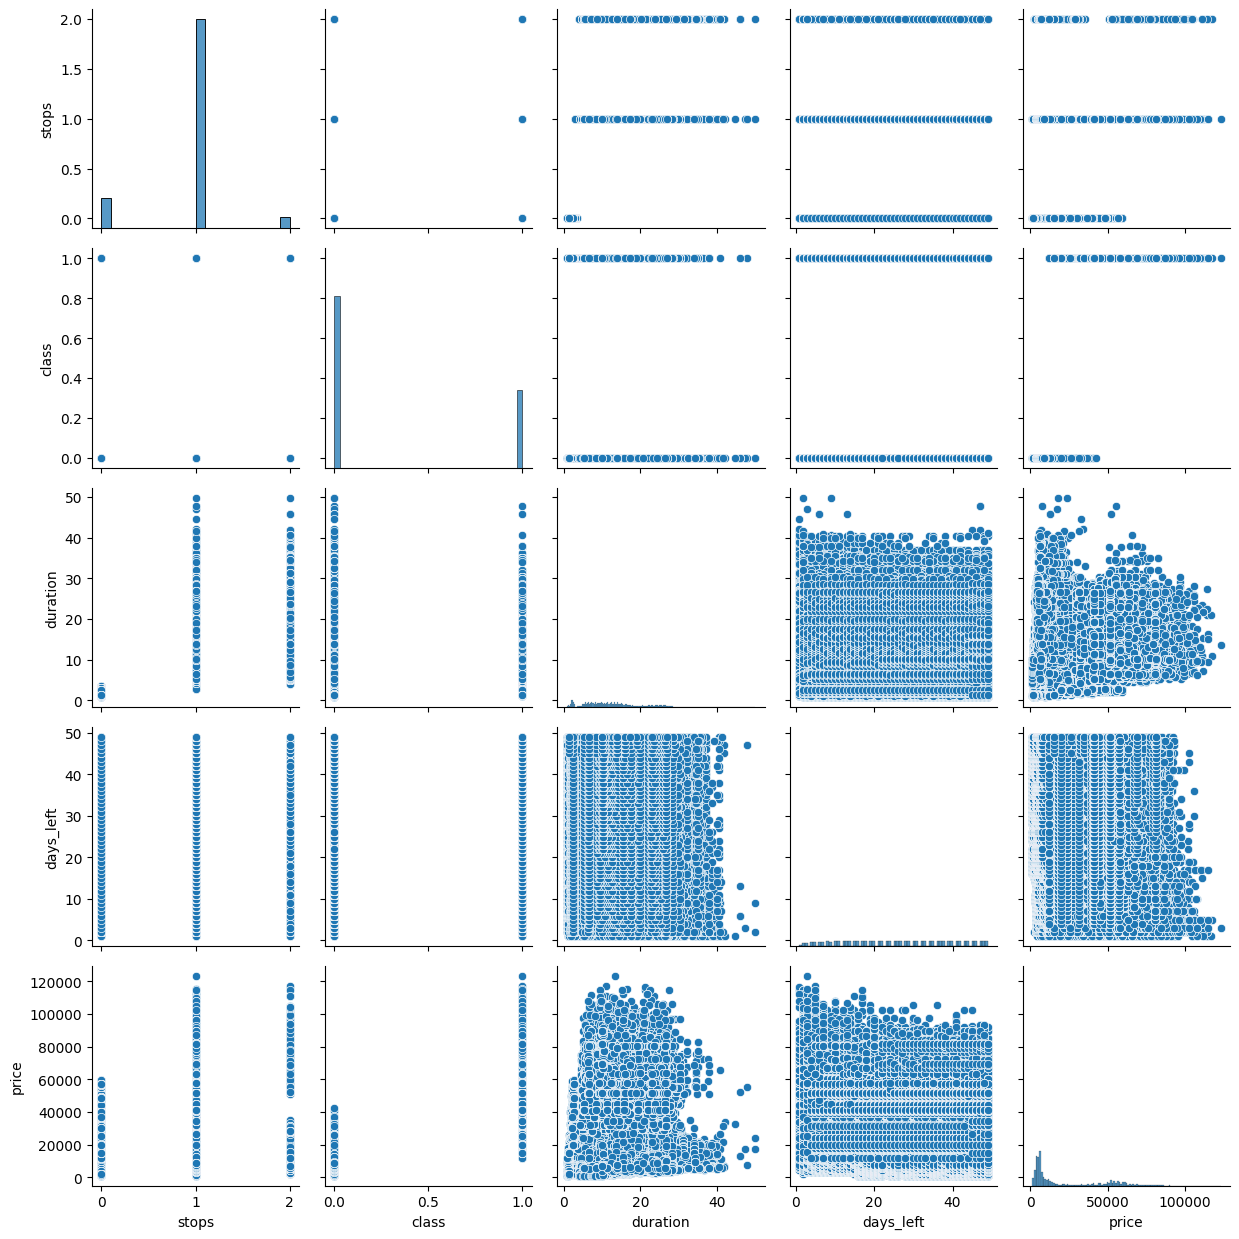

In [ ]:
sns.pairplot(df)

plt.tight_layout()
plt.show()

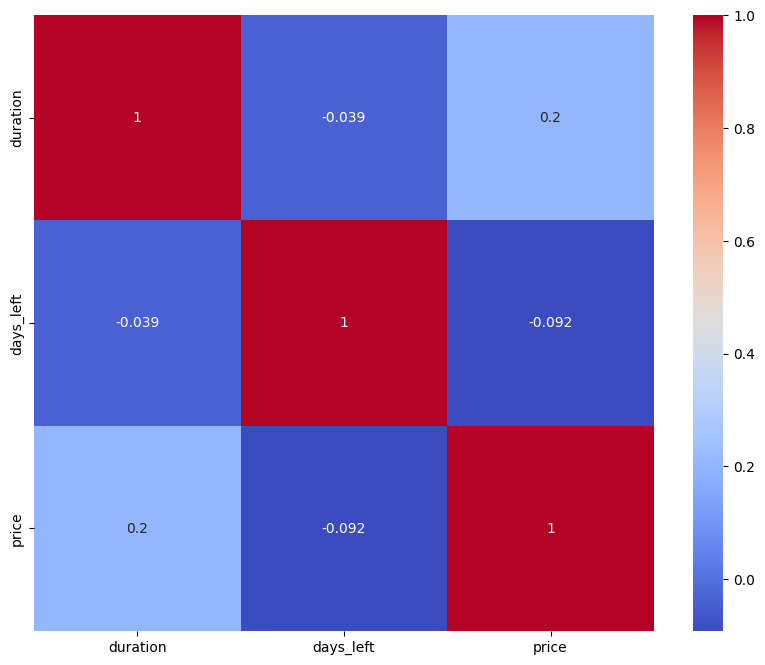

In [14]:
corr = df.corr(numeric_only= True)

sns.heatmap(corr, cmap= "coolwarm", annot= True)

plt.show()

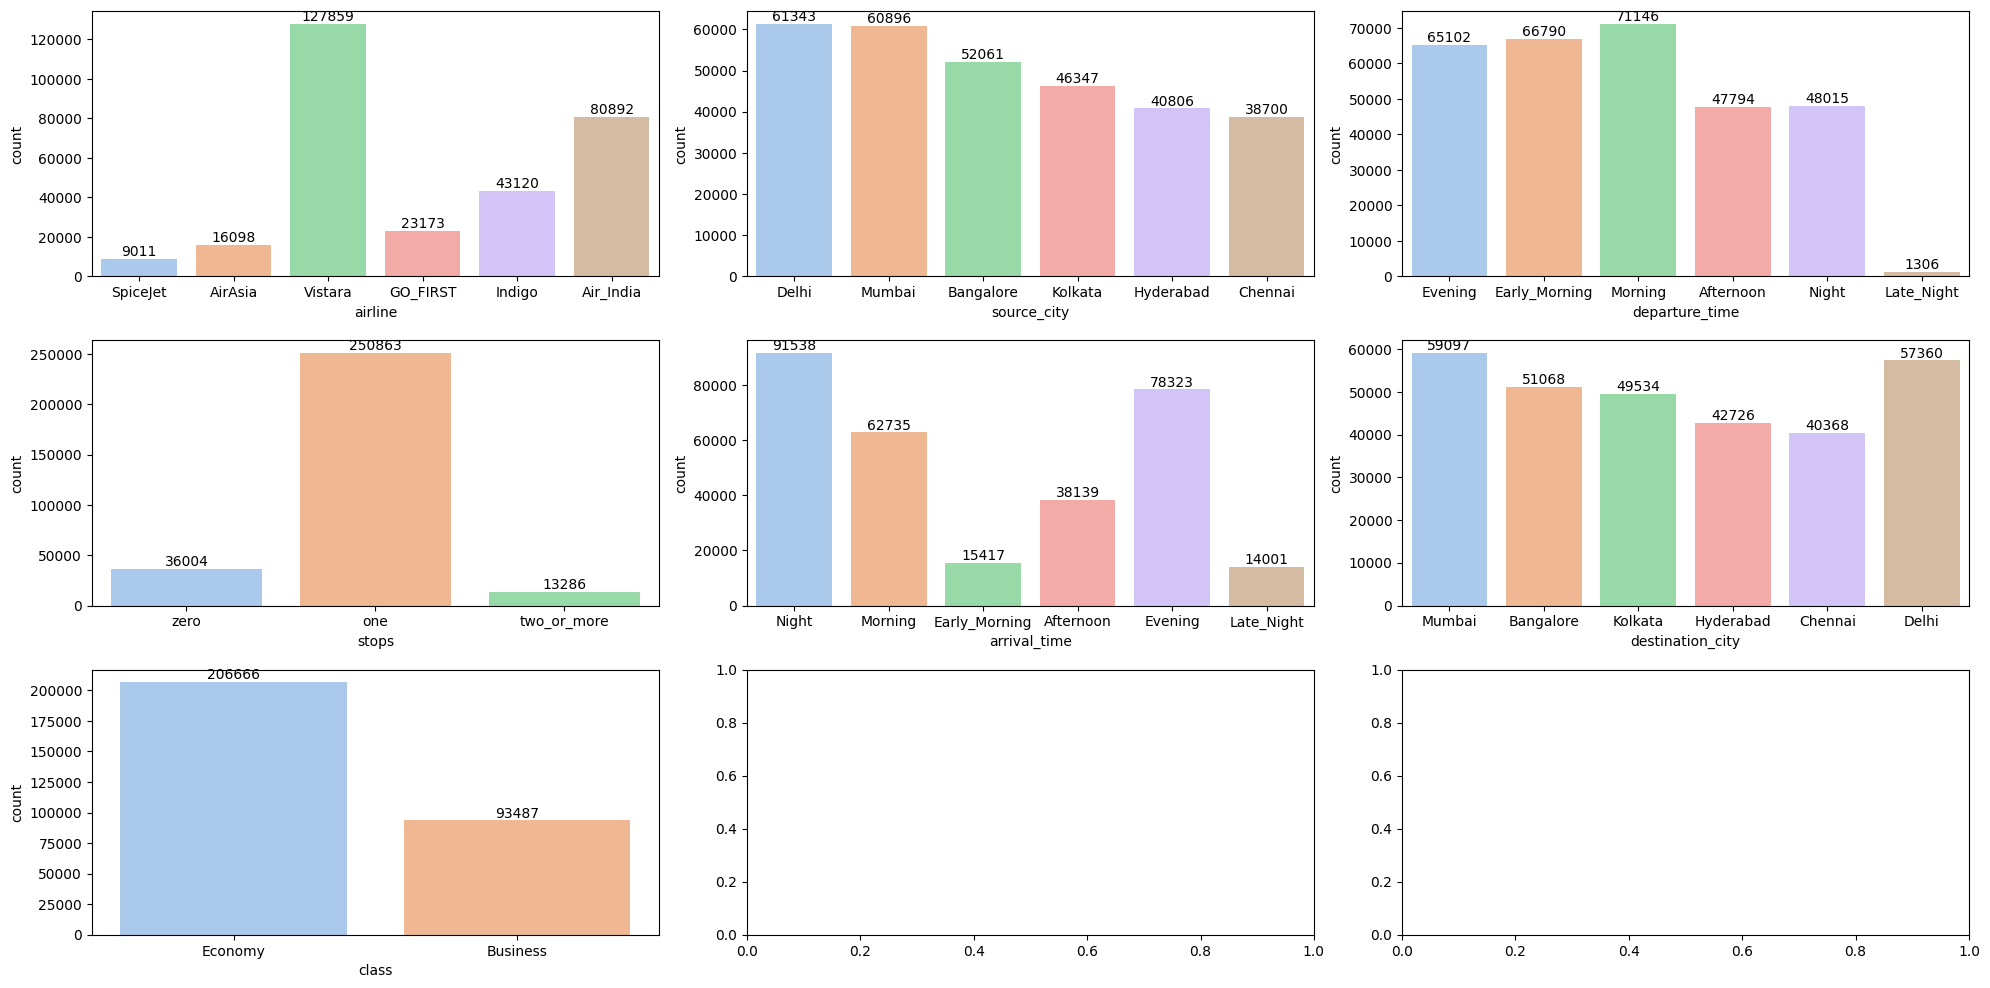

In [ ]:
# Countplot of every categoric feature
features = ['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']

col = 3
row = math.ceil(len(features) / col)

fig, ax = plt.subplots(row, col, figsize = (20, 10))
ax = ax.ravel()

for index, feature in enumerate(features):
    axis = sns.countplot(
        x= df[feature],
        ax= ax[index],
        palette= "pastel"
    )

    for container in axis.containers:
        axis.bar_label(container)

plt.tight_layout()
plt.show()

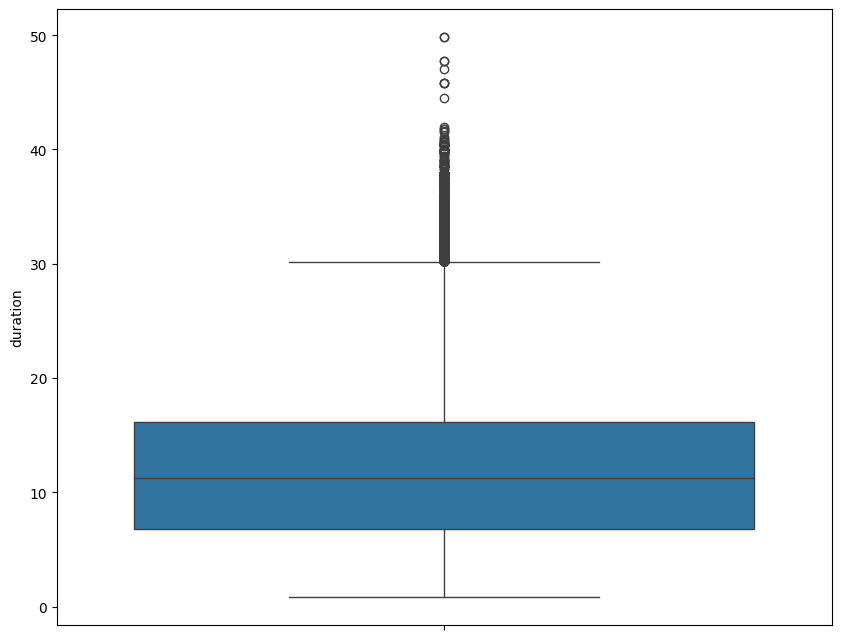

In [17]:
plt.figure(figsize= (10, 8))

sns.boxplot(df["duration"])

plt.show()

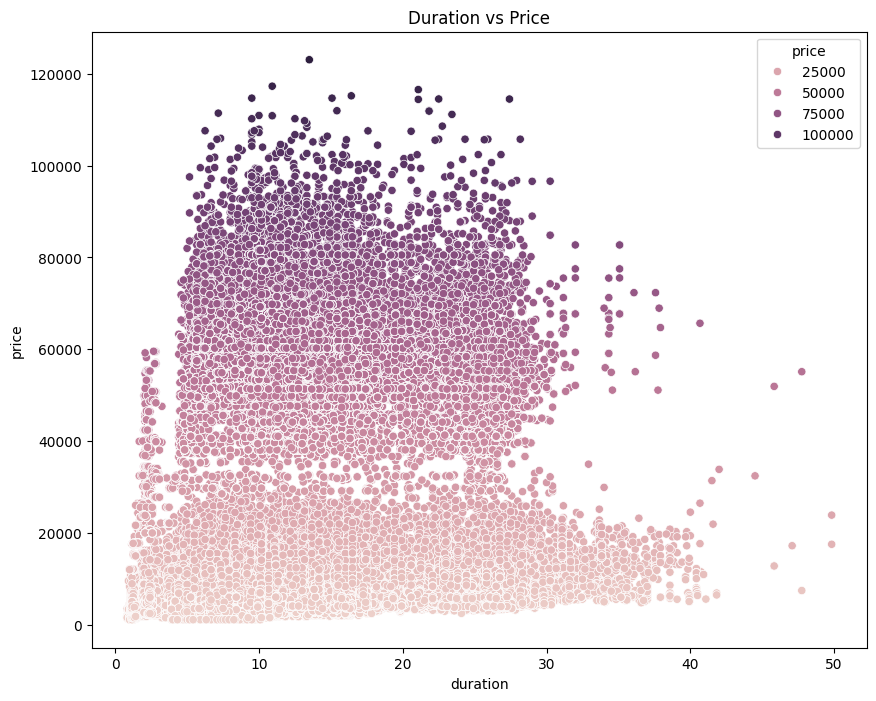

In [93]:
sns.scatterplot(
    data= df,
    x= "duration",
    y= "price",
    hue= "price"
)

plt.title("Duration vs Price")

plt.show()

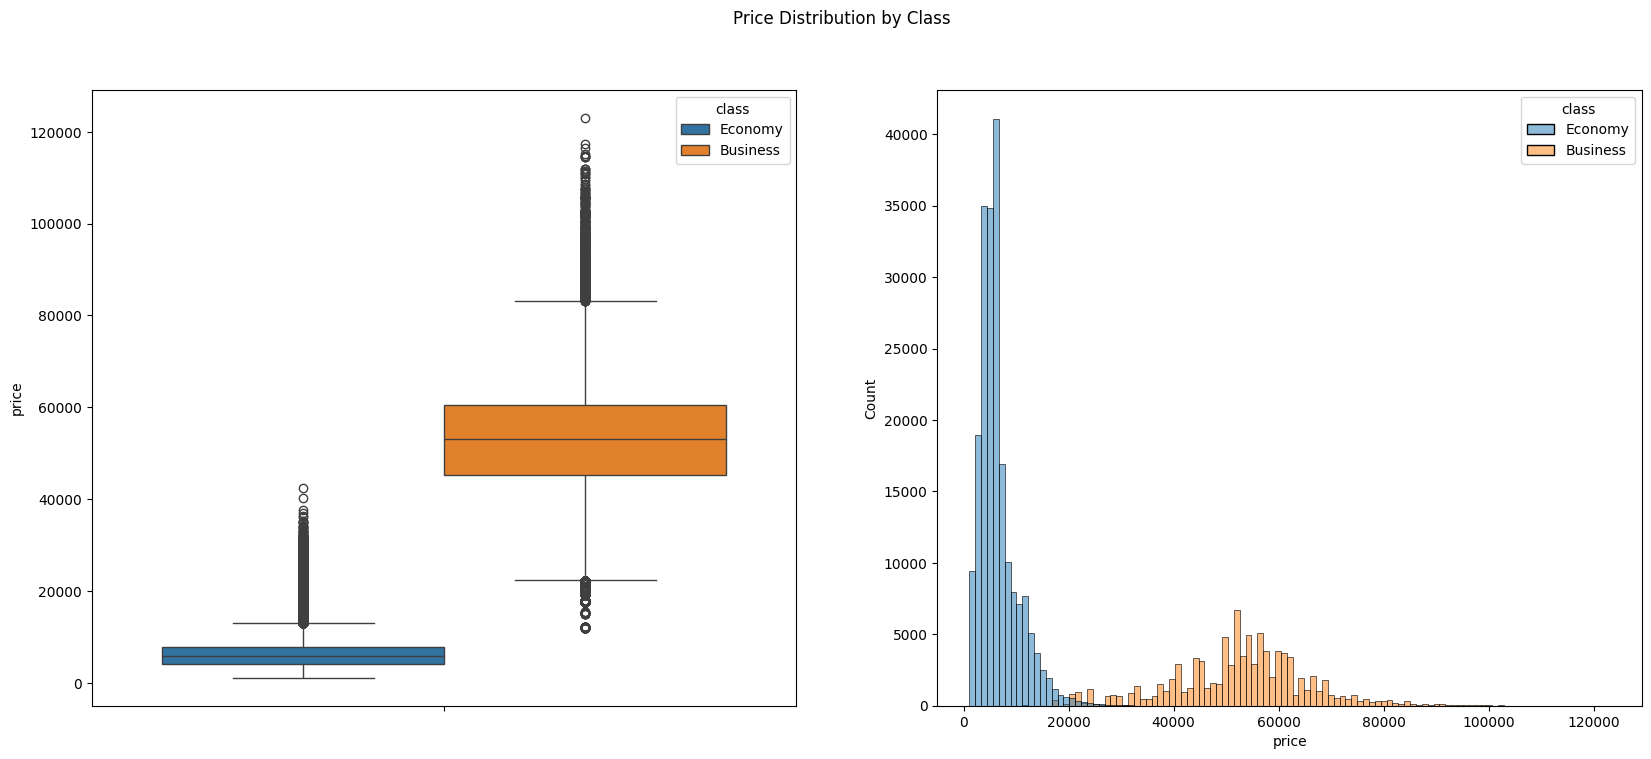

In [19]:
fig, ax = plt.subplots(1, 2, figsize = (20, 8))

sns.boxplot(
    data= df,
    y= "price",
    hue= "class",
    ax= ax[0]
)

sns.histplot(
    data= df,
    x= "price",
    hue= "class",
    ax= ax[1]
)

plt.suptitle("Price Distribution by Class")

plt.show()

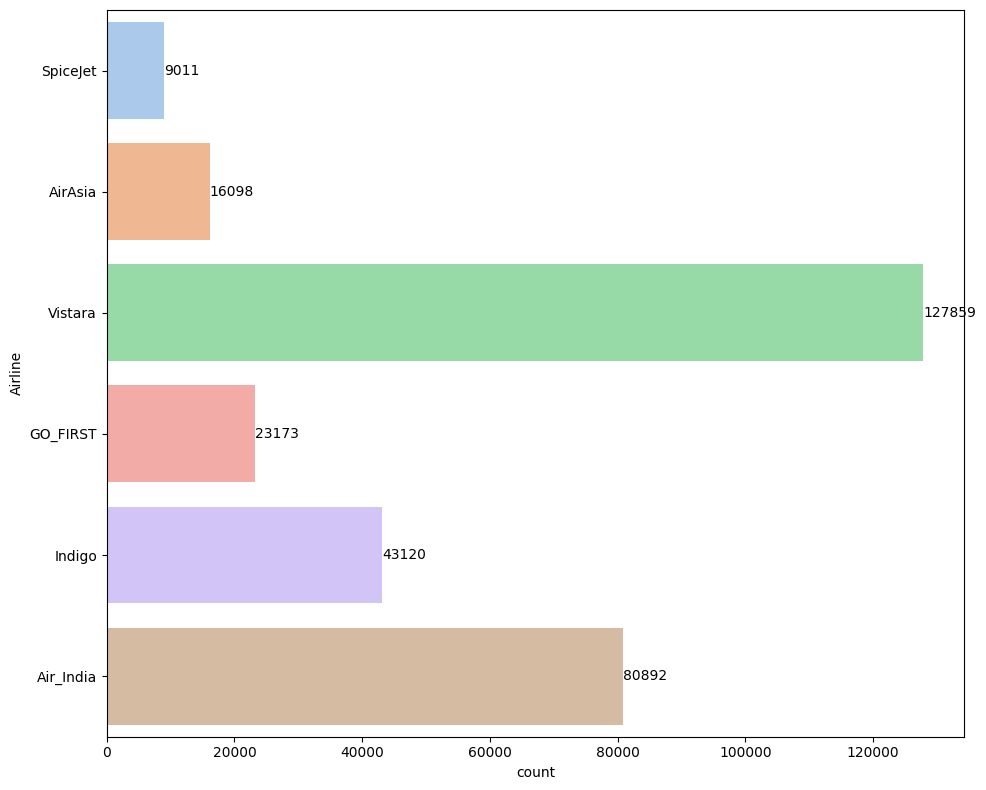

In [20]:
ax = sns.countplot(
    data= df,
    y= "airline",
    palette= "pastel"
)

for container in ax.containers:
    ax.bar_label(container)

ax.set_ylabel("Airline")

plt.tight_layout()
plt.show()

Text(0.5, 0, 'Airline')

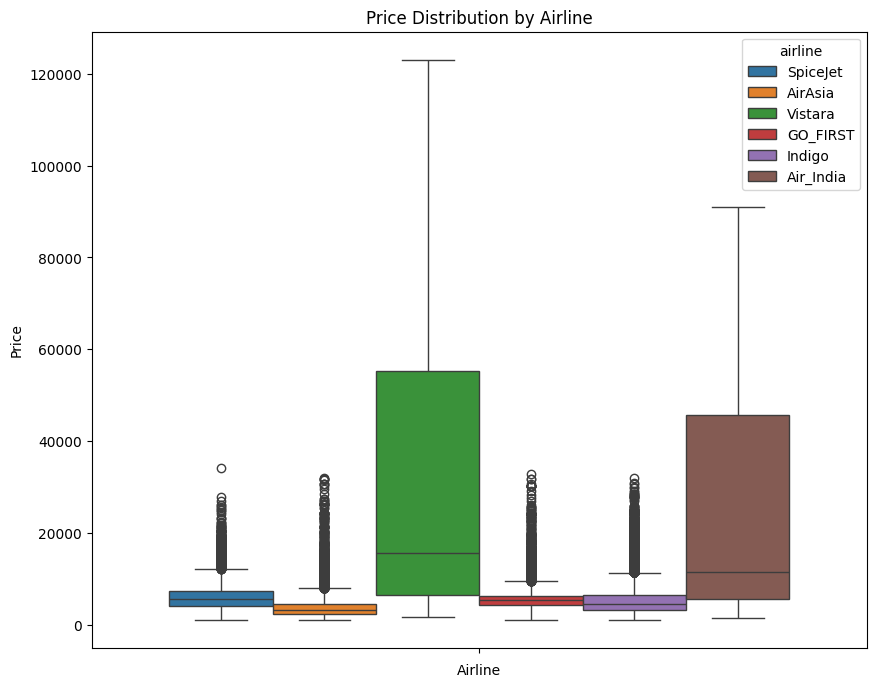

In [21]:
ax = sns.boxplot(
    data= df,
    y= "price",
    hue= "airline"
)

ax.set_title("Price Distribution by Airline")

ax.set_ylabel("Price")
ax.set_xlabel("Airline")


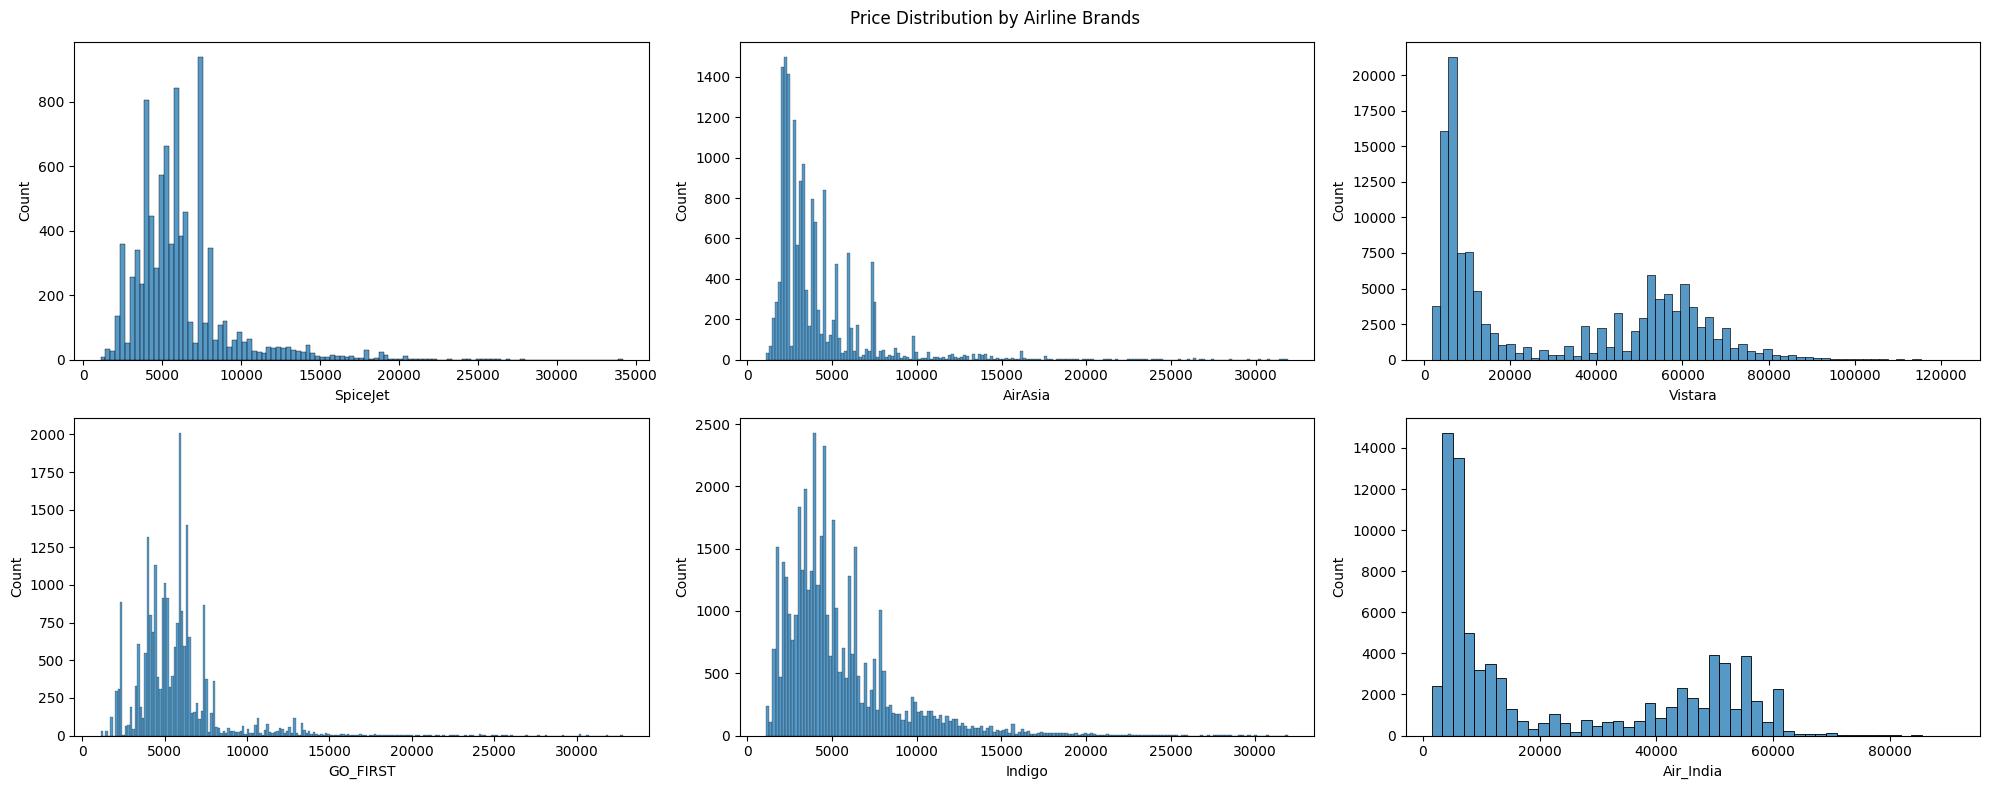

In [22]:
fig, ax = plt.subplots(2, 3, figsize = (20, 8))
ax = ax.ravel()

brands = ["SpiceJet", "AirAsia", "Vistara", "GO_FIRST", "Indigo", "Air_India"]

for index, brand in enumerate(brands):
    axis = sns.histplot(
        data= df[df["airline"] == brand],
        x= "price",
        ax= ax[index]
    )

    axis.set_xlabel(f"{brand}")

plt.suptitle("Price Distribution by Airline Brands")

plt.tight_layout()
plt.show()

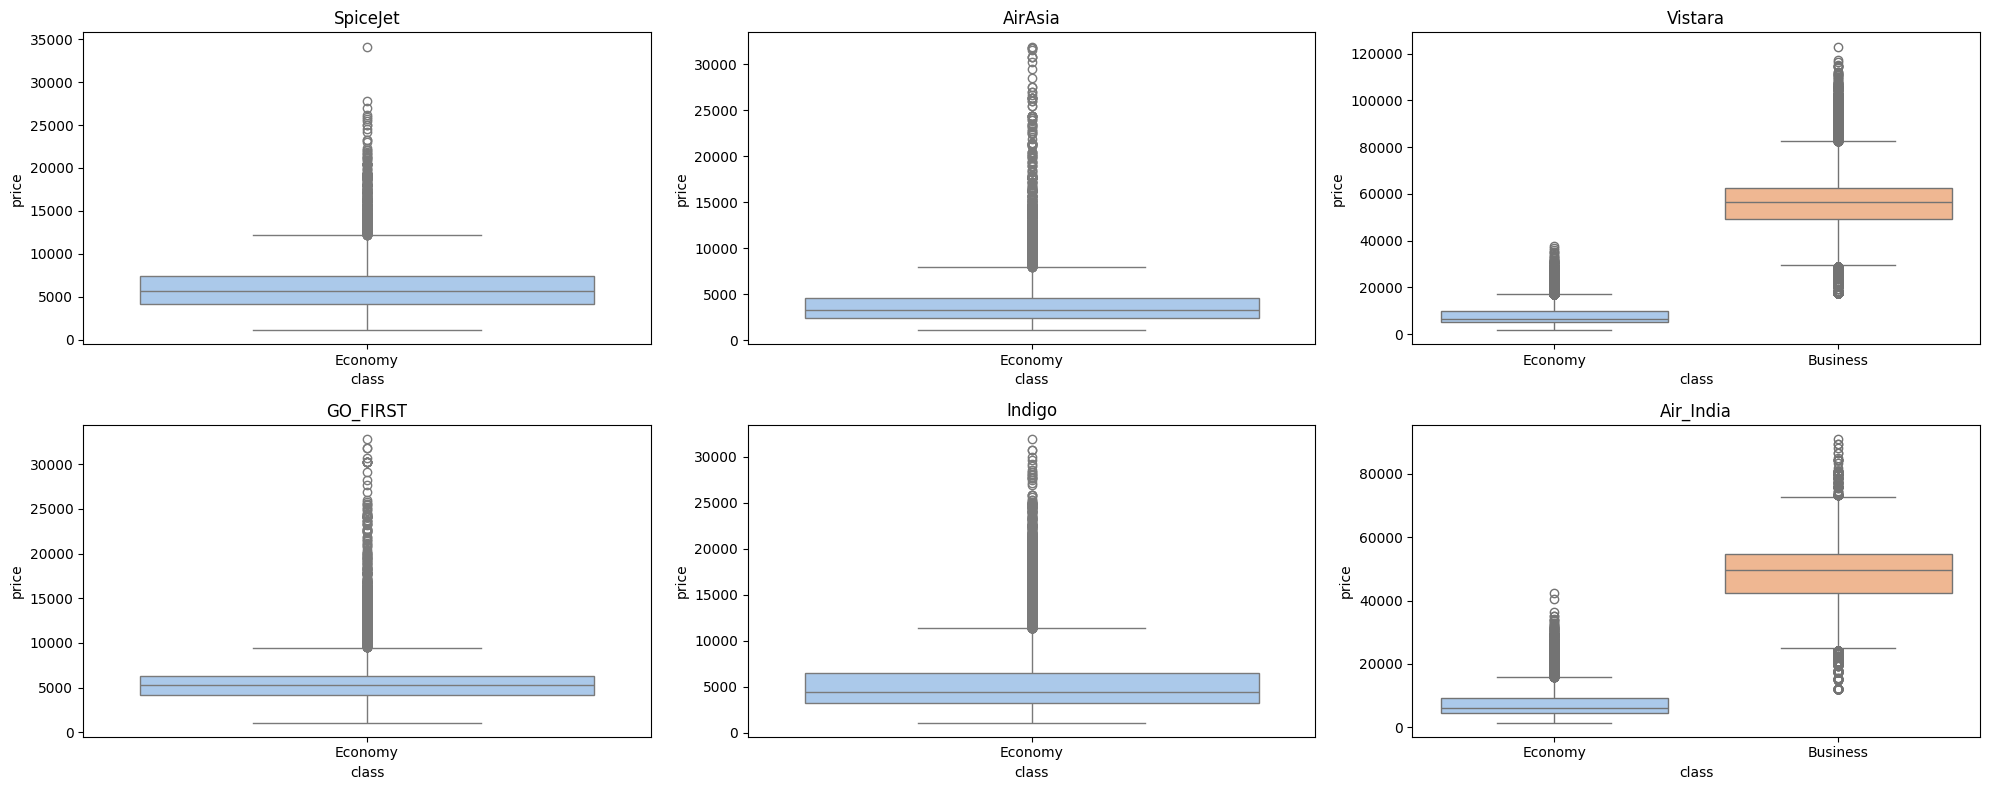

In [23]:
fig, ax = plt.subplots(2, 3, figsize = (20, 8))
ax = ax.ravel()

brands = df["airline"].unique()

for index, brand in enumerate(brands):
    axis = sns.boxplot(
        data= df[df["airline"] == brand],
        x= "class",
        y= "price",
        palette= "pastel",
        ax = ax[index]
    )

    axis.set_title(f"{brand}")

plt.tight_layout()

plt.show()

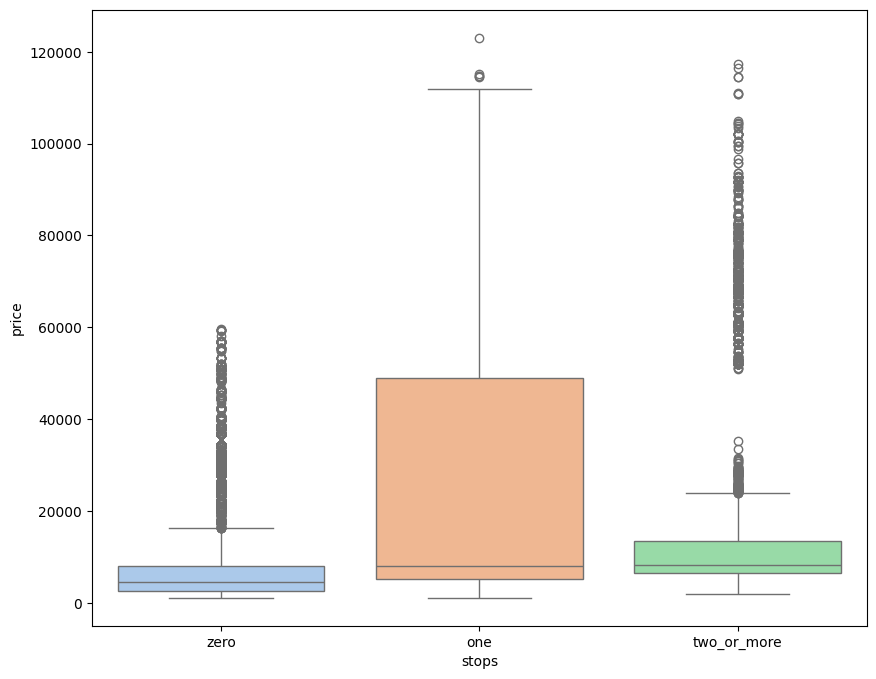

In [24]:
sns.boxplot(
    data= df,
    x= "stops",
    y= "price",
    palette= "pastel"
)

plt.show()

# Preprocessing

In [25]:
df.drop("flight", axis= 1, inplace= True)

In [26]:
df

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [27]:
df["stops"].unique()

array(['zero', 'one', 'two_or_more'], dtype=object)

In [28]:
df["stops"] = df["stops"].map({"zero" : 0, "one" : 1, "two_or_more" : 2})

In [29]:
df["class"] = df["class"].map({"Economy" : 0, "Business" : 1})

In [31]:
df

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,0,Night,Mumbai,0,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,0,Morning,Mumbai,0,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,0,Early_Morning,Mumbai,0,2.17,1,5956
3,Vistara,Delhi,Morning,0,Afternoon,Mumbai,0,2.25,1,5955
4,Vistara,Delhi,Morning,0,Morning,Mumbai,0,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,Chennai,Morning,1,Evening,Hyderabad,1,10.08,49,69265
300149,Vistara,Chennai,Afternoon,1,Night,Hyderabad,1,10.42,49,77105
300150,Vistara,Chennai,Early_Morning,1,Night,Hyderabad,1,13.83,49,79099
300151,Vistara,Chennai,Early_Morning,1,Evening,Hyderabad,1,10.00,49,81585


In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X = df.drop("price", axis= 1)
y = df["price"]

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [35]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [36]:
categoric_cols = df.select_dtypes(include= "object").columns

In [37]:
categoric_cols

Index(['airline', 'source_city', 'departure_time', 'arrival_time',
       'destination_city'],
      dtype='object')

In [38]:
preprocessor = ColumnTransformer(
    transformers= [
        ("One-Hot Encoding", OneHotEncoder(), categoric_cols)
    ],
    remainder= "passthrough"
)

In [39]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Training

In [40]:
from sklearn.tree import DecisionTreeRegressor

In [41]:
regressor = DecisionTreeRegressor()

In [42]:
regressor.fit(X_train_transformed, y_train)

DecisionTreeRegressor()

In [43]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [44]:
predicts = regressor.predict(X_test_transformed)

print(f"MSE : {mean_squared_error(y_test, predicts)}")
print(f"MAE : {mean_absolute_error(y_test, predicts)}")
print(f"r2 Score : {r2_score(y_test, predicts):.2%}")

MSE : 12439105.685675366
MAE : 1162.0256922812105
r2 Score : 97.59%


In [46]:
print(f"Train R2 : {regressor.score(X_train_transformed, y_train):.2%}")
print(f"Test R2 : {regressor.score(X_test_transformed, y_test):.2%}")

Train R2 : 99.93%
Test R2 : 97.59%


In [67]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [94]:
regressor = DecisionTreeRegressor()

In [ ]:
splitter = ["best", "random"]
criterion = ["squared_error", "poisson"]
max_depth = [10, 20, 50, 100]
min_samples_split = [5, 10, 15, 20]
max_features = ["sqrt", "log2"]

In [75]:
params = dict(
    splitter = splitter,
    criterion = criterion,
    max_depth = max_depth,
    min_samples_split = min_samples_split,
    max_features = max_features
)

In [76]:
random = RandomizedSearchCV(
    estimator= regressor,
    param_distributions= params,
    cv= 5,
    random_state= 42,
    n_jobs= -1,
    n_iter= 30
)

In [77]:
random.fit(X_train_transformed, y_train)

RandomizedSearchCV(cv=5, estimator=DecisionTreeRegressor(), n_iter=30,
                   n_jobs=-1,
                   param_distributions={'criterion': ['squared_error',
                                                      'poisson'],
                                        'max_depth': [10, 20, 50, 100],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_split': [5, 10, 15, 20],
                                        'splitter': ['best', 'random']},
                   random_state=42)

In [78]:
random.best_estimator_

DecisionTreeRegressor(criterion='poisson', max_depth=50, max_features='log2',
                      min_samples_split=5, splitter='random')

In [79]:
random.best_params_

{'splitter': 'random',
 'min_samples_split': 5,
 'max_features': 'log2',
 'max_depth': 50,
 'criterion': 'poisson'}

In [80]:
predicts = random.predict(X_test_transformed)

print(f"MSE : {mean_squared_error(y_test, predicts)}")
print(f"MAE : {mean_absolute_error(y_test, predicts)}")
print(f"r2 Score : {r2_score(y_test, predicts):.2%}")

MSE : 23794380.776448954
MAE : 1806.6868326364709
r2 Score : 95.38%


In [95]:
regressor = DecisionTreeRegressor()

In [81]:
splitter = ["best", "random"]
max_depth = [10, 20, 50, 100]
min_samples_split = [5, 10, 15, 20]

In [82]:
params = dict(
    splitter = splitter,
    max_depth = max_depth,
    min_samples_split = min_samples_split,
)

In [ ]:
grid = GridSearchCV(
    estimator= regressor,
    param_grid= params,
    cv= 5,
    n_jobs= -1
)

In [85]:
grid.fit(X_train_transformed, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(), n_jobs=-1,
             param_grid={'max_depth': [10, 20, 50, 100],
                         'min_samples_split': [5, 10, 15, 20],
                         'splitter': ['best', 'random']})

In [86]:
grid.best_estimator_

DecisionTreeRegressor(max_depth=100, min_samples_split=20)

In [87]:
grid.best_params_

{'max_depth': 100, 'min_samples_split': 20, 'splitter': 'best'}

In [88]:
predicts = grid.predict(X_test_transformed)

print(f"MSE : {mean_squared_error(y_test, predicts)}")
print(f"MAE : {mean_absolute_error(y_test, predicts)}")
print(f"r2 Score : {r2_score(y_test, predicts):.2%}")

MSE : 9069650.382444087
MAE : 1208.827243871981
r2 Score : 98.24%


In [90]:
print(f"Train R2 : {grid.score(X_train_transformed, y_train):.2%}")
print(f"Test R2 : {grid.score(X_test_transformed, y_test):.2%}")

Train R2 : 99.06%
Test R2 : 98.24%
